In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
student_name = "Jocel Golisao"
student_id = "TUPM-25-0803" # Replace with your actual ID
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5)
% 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4)
% 256:02x}"

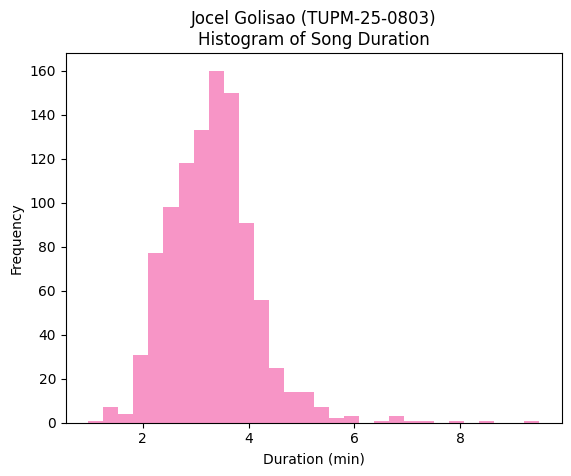

In [46]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

C:\Users\Ramstore\AppData\Local\Temp\ipykernel_15196\3815968401.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


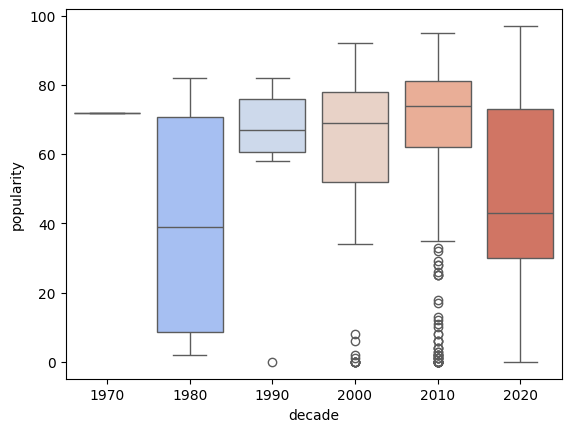

In [63]:
df['decade'] = (pd.to_datetime(df['release_date'], format='mixed').dt.year // 10) * 10
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
plt.show()

C:\Users\Ramstore\AppData\Local\Temp\ipykernel_15196\2261941100.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')


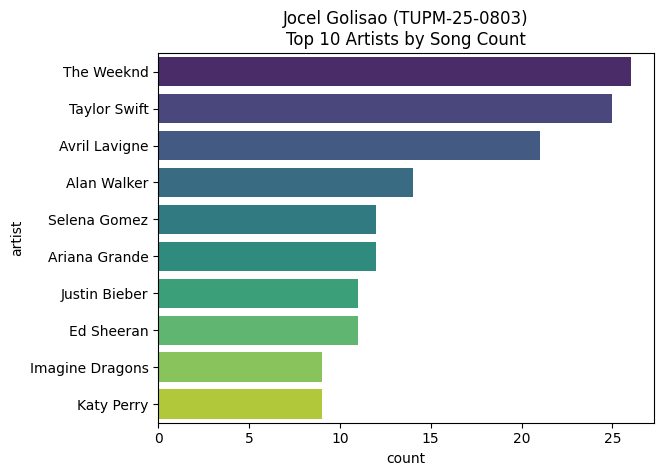

In [58]:
sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

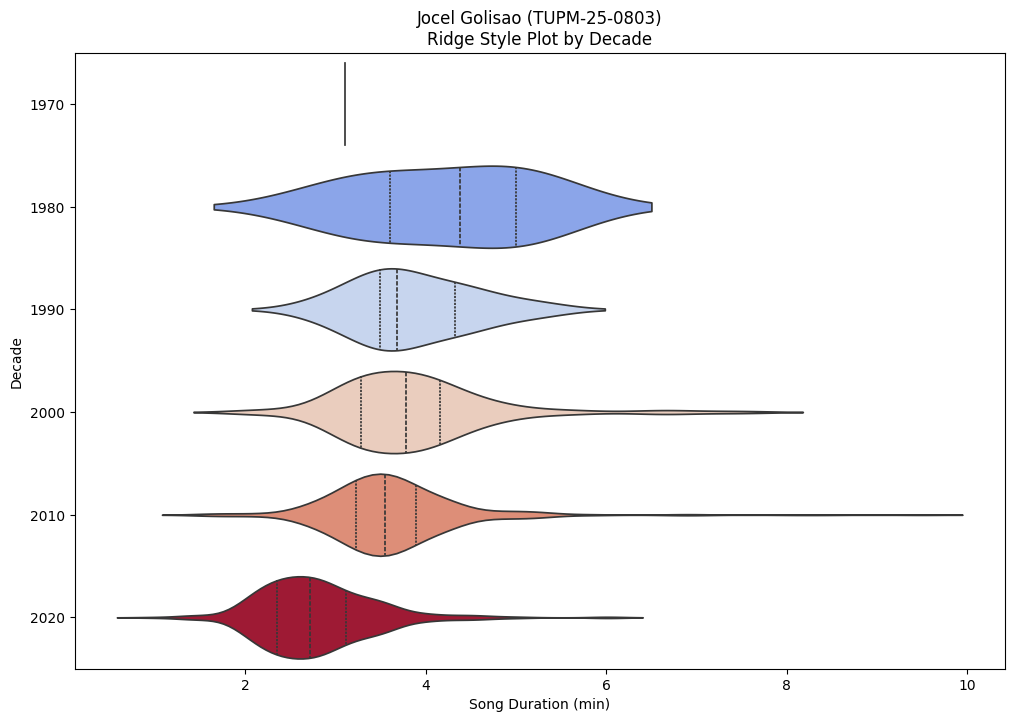

In [91]:
plt.figure(figsize=(12, 8))

df['decade'] = (pd.to_datetime(df['release_date'], format='mixed').dt.year // 10) * 10

sns.violinplot(
    data=df, 
    x='duration_min', 
    y='decade', 
    orient='h',            
    palette='coolwarm', 
    inner='quartile',      
    hue='decade',          
    legend=False
)


plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.xlabel("Song Duration (min)")
plt.ylabel("Decade")

plt.show()

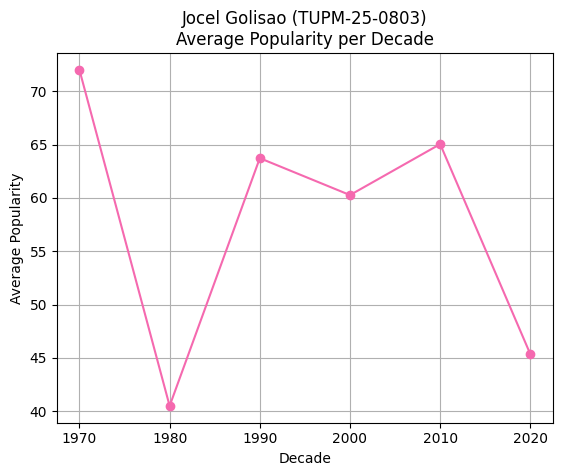

In [64]:
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()


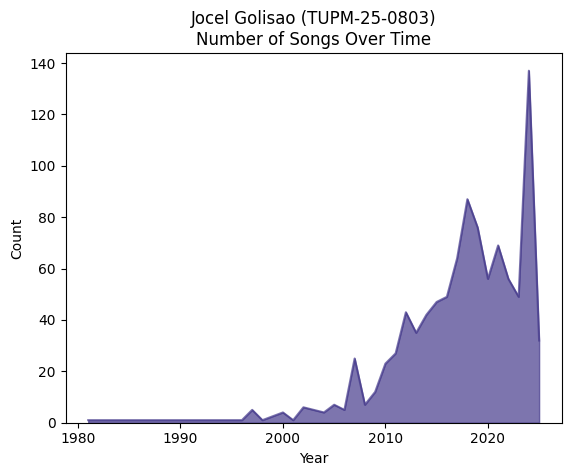

In [65]:
df['release_year'] = pd.to_datetime(df['release_date'],
errors='coerce').dt.year
count_by_year = df['release_year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


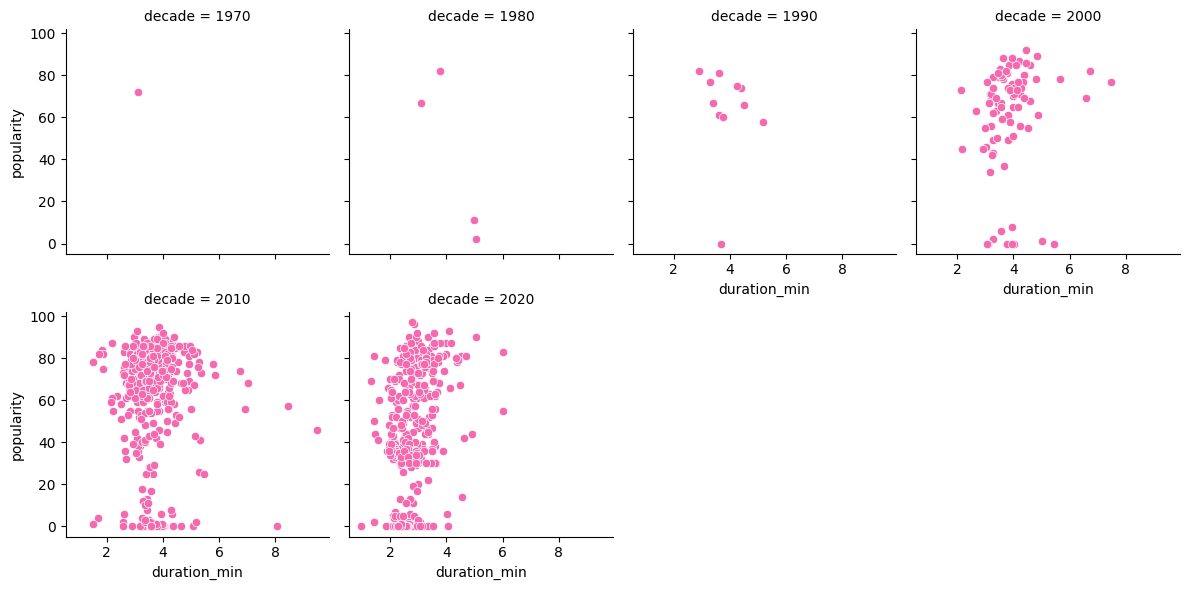

In [67]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity',
color=color1)
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
plt.show()

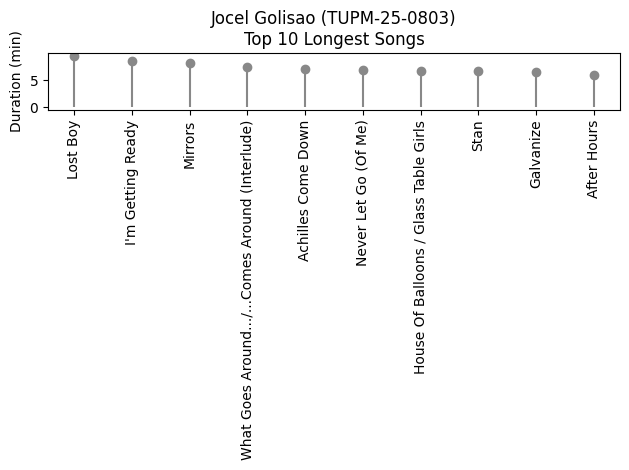

In [68]:
longest = df.nlargest(10, 'duration_min')
plt.stem(longest['track_name'], longest['duration_min'],
linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

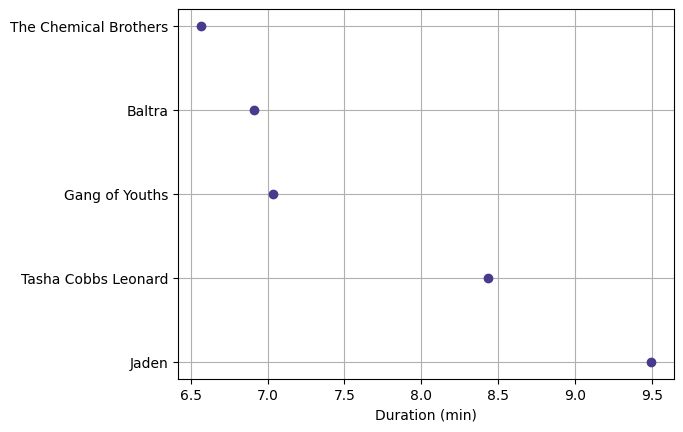

In [70]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"
plt.xlabel('Duration (min)')
plt.grid(True)
plt.show()


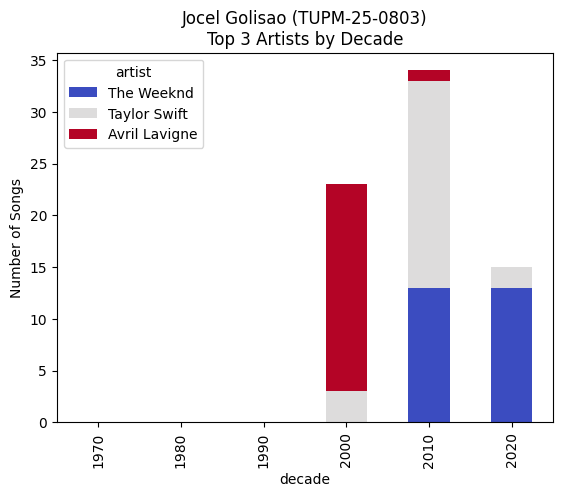

In [71]:
crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()


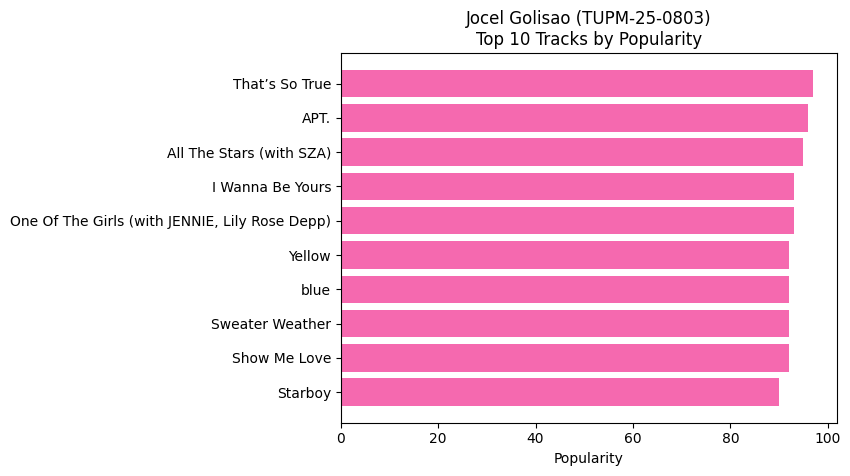

In [72]:
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()

C:\Users\Ramstore\AppData\Local\Temp\ipykernel_15196\689365534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\Ramstore\AppData\Local\Temp\ipykernel_15196\689365534.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


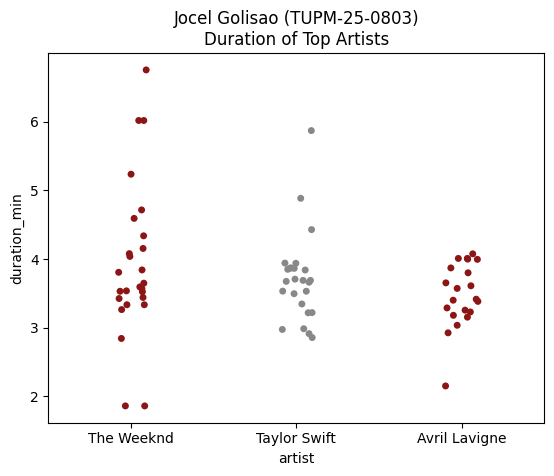

In [73]:
top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
y='duration_min', palette=['#8C1515', '#888888'])
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()


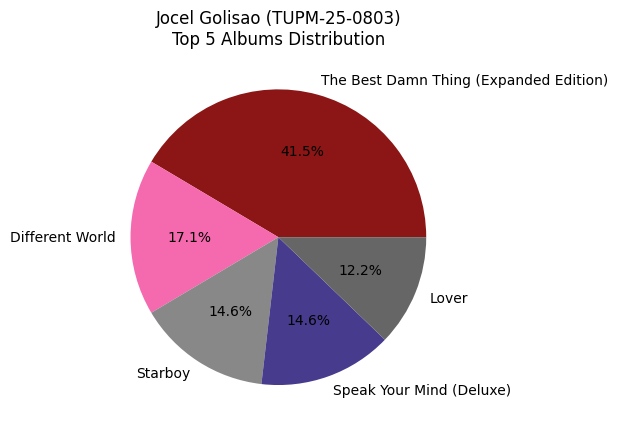

In [74]:
top_albums = df['album'].value_counts().head(5)
colors = ['#8C1515', color1, '#888888', color2, '#666666']
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%',
colors=colors)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

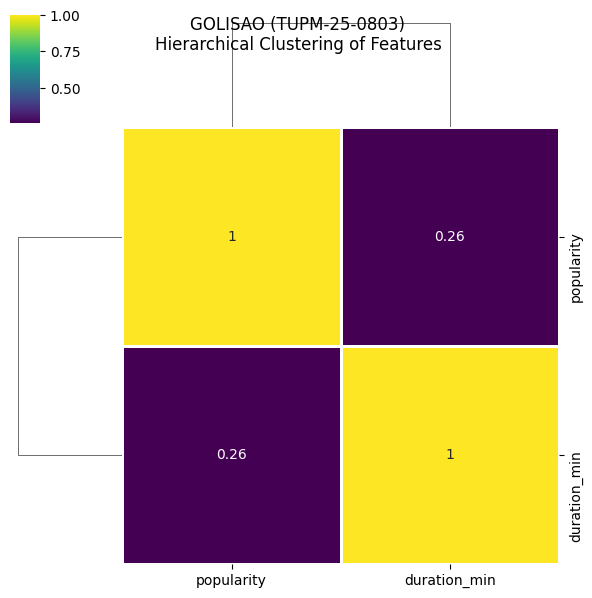

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Replace 'your_data.csv' with your actual file name
csv_files = r"C:\Users\Ramstore\Documents\Activity 7\spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)
# These must be defined for the plot to work
student_name = "GOLISAO"
student_id = "TUPM-25-0803"

numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()

sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', linewidths=.75, figsize=(6, 6))
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features")
plt.show()

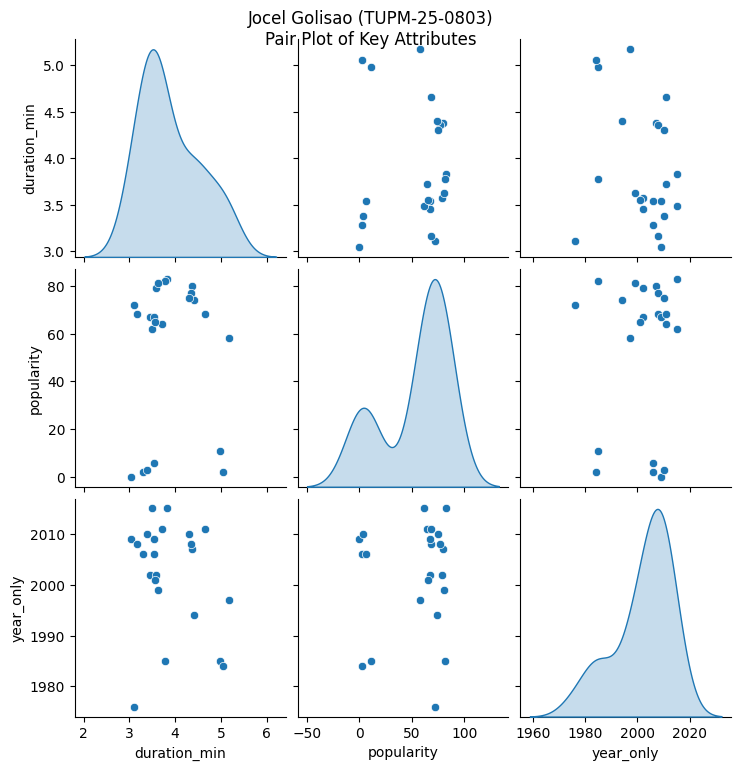

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

csv_files = r"C:\Users\Ramstore\Documents\Activity 7\spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)

df['year_only'] = pd.to_numeric(df['release_date'], errors='coerce')
df_clean = df.dropna(subset=['year_only', 'popularity', 'duration_min'])

sns.pairplot(df_clean[['duration_min', 'popularity', 'year_only']], diag_kind='kde')

plt.suptitle(f"Jocel Golisao (TUPM-25-0803)\nPair Plot of Key Attributes", y=1.02)

plt.show()

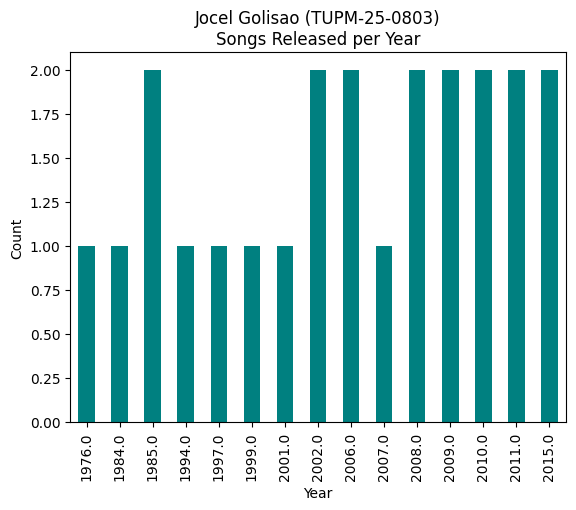

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

csv_files = r"C:\Users\Ramstore\Documents\Activity 7\spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)
color2 = 'teal' 

df['release_year'] = pd.to_numeric(df['release_date'], errors='coerce')

df['release_year'].value_counts().sort_index().plot(kind='bar', color=color2)

plt.title(f"Jocel Golisao (TUPM-25-0803)\nSongs Released per Year")
plt.ylabel('Count')
plt.xlabel('Year')

plt.show()


C:\Users\Ramstore\AppData\Local\Temp\ipykernel_19528\3436879342.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity',


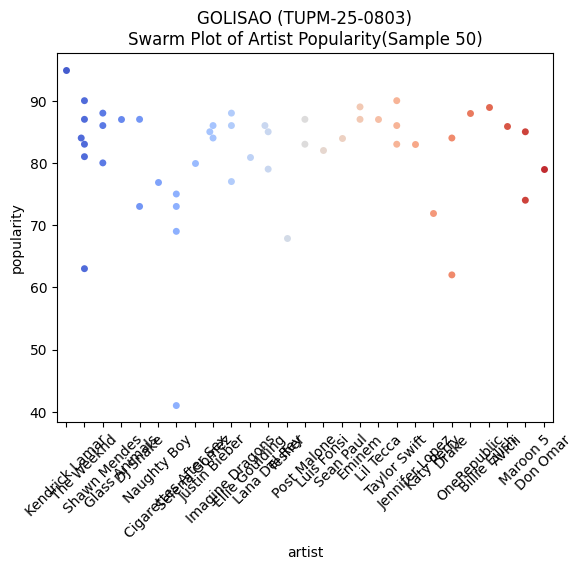

In [6]:
sns.swarmplot(data=df.head(50), x='artist', y='popularity',
palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity(Sample 50)")
plt.xticks(rotation=45)
plt.show()


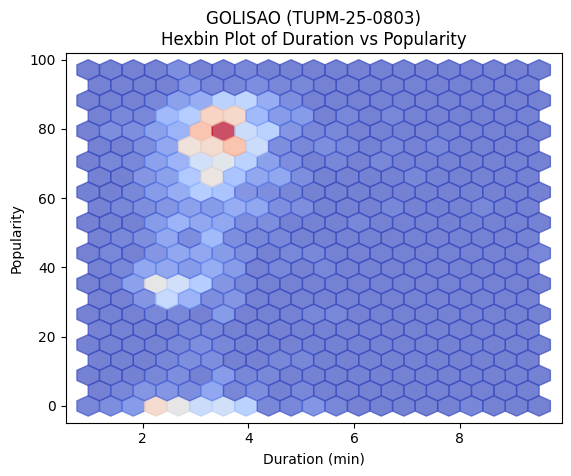

In [8]:
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20,
cmap='coolwarm', alpha=0.7)
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
plt.show()

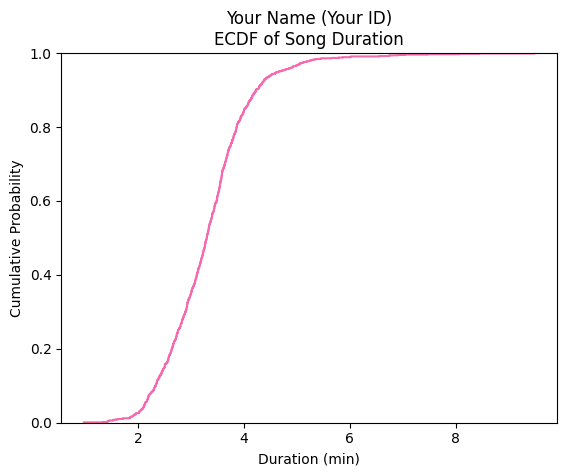

In [132]:
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()


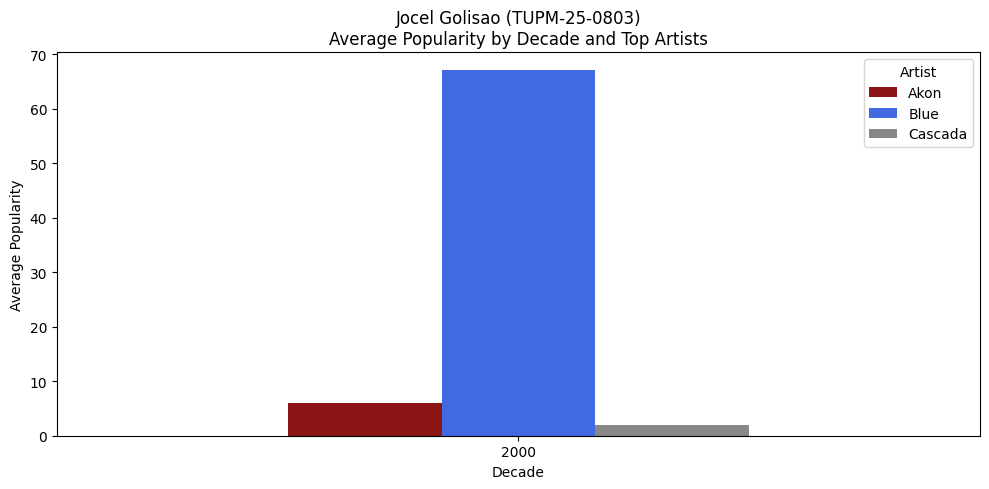

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

csv_files = r"C:\Users\Ramstore\Documents\Activity 7\spotify_top_1000_tracks.csv"

df['release_year'] = pd.to_numeric(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_year', 'popularity'])

df['decade'] = (df['release_year'] // 10).astype(int) * 10

top3 = df['artist'].value_counts().head(3).index

df_top3 = df[df['artist'].isin(top3)]
avg_artist_decade = df_top3.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)

if not avg_artist_decade.empty:
    avg_artist_decade.plot(kind='bar', figsize=(10, 5), color=['#8C1515', 'royalblue', '#888888'])
    
    plt.title(f"Jocel Golisao (TUPM-25-0803)\nAverage Popularity by Decade and Top Artists")
    plt.ylabel('Average Popularity')
    plt.xlabel('Decade')
    plt.legend(title='Artist')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Error: No numeric data available for the selected artists and decades.")